(416, 612, 3)
(3, 416, 612)
416 612 3
(0.39385226281310043, 0.40925482309586997, 0.4069187824704904)


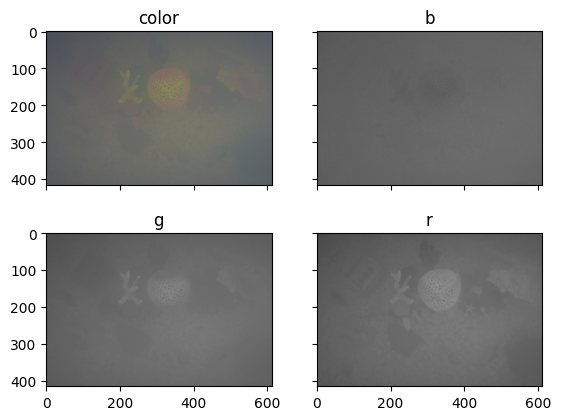

In [270]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass

from pathlib import Path
from typing import Iterable
import math

from enum import Enum

class StatType(Enum):
    Min = 0
    Max = 1
    Mean = 2

@dataclass
class MinMaxMean:
    min: float
    max: float
    mean: float = None

class Stats:
    def __init__(self, stat_list: tuple[MinMaxMean, MinMaxMean, MinMaxMean]):
        self._stat_list = stat_list
        self._by_stat_type = {
            StatType.Min: tuple([mmm.min for mmm in self._stat_list]),
            StatType.Max: tuple([mmm.max for mmm in self._stat_list]),
            StatType.Mean: tuple([mmm.mean for mmm in self._stat_list])
        }

    @staticmethod
    def from_img(img_cl: np.ndarray):
        means = cv2.mean(img_cl)[:-1]  # Remove fourth channel mean

        # [(min, max, (min_loc), (max_loc)), ..., ...]
        channel_min_max_locs = [cv2.minMaxLoc(c) for c in cv2.split(img_cl)]
        # [(min, max), ..., ...]
        extremes = [(locs[0], locs[1]) for locs in channel_min_max_locs]

        return Stats((
            MinMaxMean(extremes[0][0], extremes[0][1], means[0]),
            MinMaxMean(extremes[1][0], extremes[1][1], means[1]),
            MinMaxMean(extremes[2][0], extremes[2][1], means[2])
        ))

    def channel(self, channel_index: int) -> MinMaxMean:
        return self._stat_list[channel_index]

    def stat_array(self, stat_type: StatType) -> tuple[float, float, float]:
        return self._by_stat_type[stat_type]

    def channel_idxs_sorted_by(self, stat_type: StatType) -> tuple[int, int, int]:
        return np.argsort(self.stat_array(stat_type))

def channel_first_to_last(img_cf: np.ndarray) -> np.ndarray:
    return np.transpose(img_cf, (1, 2, 0))

def channel_last_to_first(img_cl: np.ndarray) -> np.ndarray:
    return np.transpose(img_cl, (2, 0, 1))

def plot_channels(img_cl: np.ndarray[np.float64]) -> None:
    plot_imgs([img_cl, *cv2.split(img_cl)], titles=('color', 'b', 'g', 'r'))

def plot_imgs(imgs: Iterable[np.ndarray], grouped: bool = True,
              max_cols: int = 2, titles: tuple[str, ...] = None) -> None:
    if titles is None:
        titles = [str(x) for x in range(len(imgs))]

    if grouped:
        num_rows = math.ceil(len(imgs) / max_cols)
        fig, ax = plt.subplots(nrows=num_rows, ncols=max_cols, sharex=True, sharey=True)
        # ax = ax.flatten()
        for r in range(num_rows):
            for c in range(max_cols):
                img_idx = r * max_cols + c
                if img_idx < len(imgs):
                    if len(imgs[img_idx].shape) == 3:
                        ax[r, c].imshow(imgs[img_idx][:,:,::-1])  # Reverse BGR -> RGB
                    else:
                        ax[r, c].imshow(imgs[img_idx], cmap='gray', vmin=0.0, vmax=1.0)
                    ax[r, c].title.set_text(titles[img_idx])
        plt.show()
    else:
        for img in imgs:
            plot_img(img)

def plot_img(img: np.ndarray, show_plot: bool = True) -> None:
    if len(img.shape) == 3:
        img = img[:,:,::-1]  # Reverse BGR -> RGB
    plt.imshow(img)
    if show_plot:
        plt.show()

PATH = Path('milk') / 'a16.jpg'

img_cl = cv2.imread(str(PATH))
img_cl = cv2.resize(img_cl, (img_cl.shape[1] // 6, img_cl.shape[0] // 6))
img_cl = img_cl.astype(np.float64) / 255.0
img_cf = channel_last_to_first(img_cl)

img_cl_og = np.copy(img_cl)

def set_img_cl(new_img_cl: np.ndarray) -> None:
    global img_cl, img_cf
    img_cl = new_img_cl
    img_cf = channel_last_to_first(new_img_cl)

print(img_cl.shape)
print(img_cf.shape)

H, W, C = img_cl.shape
print(H, W, C)

print(Stats.from_img(img_cl).stat_array(StatType.Mean))

plot_channels(img_cl)

# B. Dynamic Turbid Color Correction

0 2 1
OG means: (0.39385226281310043, 0.40925482309586997, 0.4069187824704904)
Increase c_l range: (0.39385226281310043, 0.47823708362075146, 0.4069187824704904, 0.0)
Adjust c_m & c_s: (0.4782370836206625, 0.47823708362075146, 0.478237083620463, 0.0)


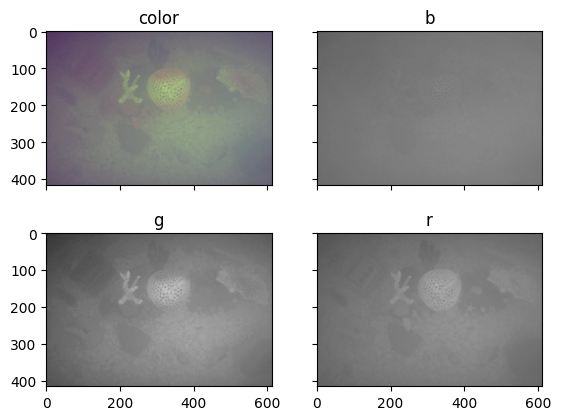

In [271]:
COLOR_LOSS_EPSILON = 0.1

def color_loss(img_cl: np.ndarray, c_s, c_m, c_l):
    stats = Stats.from_img(img_cl)
    means = stats.stat_array(StatType.Mean)
    return np.abs(means[c_l] - means[c_m]) + np.abs(means[c_l] - means[c_s])

og_stats = Stats.from_img(img_cl)

# Find large channel l, medium channel m, smallest channel s
c_s, c_m, c_l = og_stats.channel_idxs_sorted_by(StatType.Mean)
print(c_s, c_m, c_l)

I_O = MinMaxMean(0.2, 0.8)  # Output intensity bounds

print('OG means:', og_stats.stat_array(StatType.Mean))

# Increase c_l dynamic range
coef = (I_O.max - I_O.min) / (og_stats.channel(c_l).max - og_stats.channel(c_l).min)
img_cf[c_l] = I_O.min + coef * (img_cf[c_l] - og_stats.channel(c_l).min)
print('Increase c_l range:', cv2.mean(img_cl))

# Adjust c_m & c_s relative to c_l
while COLOR_LOSS_EPSILON < color_loss(img_cl, c_s, c_m, c_l):
    stats = Stats.from_img(img_cl)
    for c in (c_s, c_m):
        coef = (stats.channel(c_l).mean - stats.channel(c).mean) / stats.channel(c_l).mean
        img_cf[c] = img_cf[c] + coef * img_cf[c_l]

print('Adjust c_m & c_s:', cv2.mean(img_cl))

plot_channels(img_cl)

# C. Advanced De-Turbid Scene Model

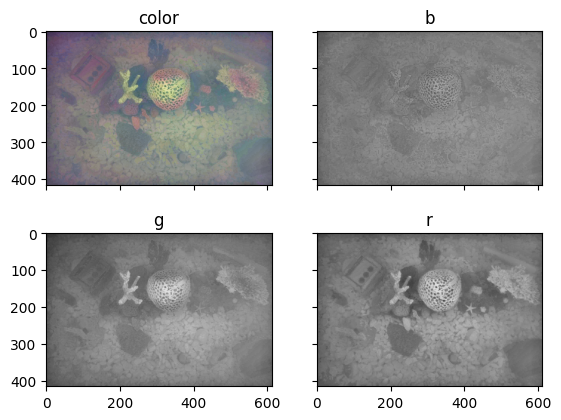

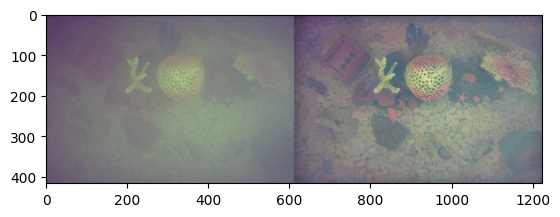

In [286]:
clahe = cv2.createCLAHE(clipLimit=5.0, tileGridSize=(8, 8))
u8_img_cf = (np.copy(img_cf) * 255).astype(np.uint8)
u8_img_cl = channel_first_to_last(u8_img_cf)
for c in (0, 1, 2):
    # u16_img_cf[c] = clahe.apply(u16_img_cf[c])
    u8_img_cf[c] = clahe.apply(u8_img_cf[c])
    # print(clahe.apply(u16_img[c]))
u8_as_floats = u8_img_cl.astype(np.float64) / 255.0
plot_channels(u8_as_floats)
plot_img(np.hstack((img_cl, u8_as_floats)))

# TODO: rewrite CLAHE to have dynamic clip limit based on block turbidity estimation